In [ ]:
import pandas as pd

df = pd.read_csv("Student Performance.csv")

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
import pandas as pd

df = pd.read_csv("Student Performance.csv")
df.head()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81


In [ ]:
print(df.columns)

Index(['student_id', 'age', 'gender', 'academic_level', 'study_hours',
       'self_study_hours', 'online_classes_hours', 'social_media_hours',
       'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes',
       'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline',
       'internet_quality', 'mental_health_score', 'focus_index',
       'burnout_level', 'productivity_score', 'exam_score'],
      dtype='object')


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
df = pd.read_csv("Student Performance.csv")

In [ ]:
df = df.drop("student_id", axis=1)

# Fill missing values with mean
df.fillna(df.mean(numeric_only=True), inplace=True)


In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop("exam_score", axis=1)
y = df["exam_score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)


In [ ]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

pr = LinearRegression()
pr.fit(X_train_poly, y_train)
y_pred_pr = pr.predict(X_test_poly)


In [ ]:
ridge = Ridge()
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)


In [ ]:
lasso = Lasso()
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)


In [ ]:
elastic = ElasticNet()
elastic.fit(X_train, y_train)
y_pred_elastic = elastic.predict(X_test)



In [ ]:
models = {
    "Linear": y_pred_lr,
    "Polynomial": y_pred_pr,
    "Ridge": y_pred_ridge,
    "Lasso": y_pred_lasso,
    "ElasticNet": y_pred_elastic
}

results = []

for name, pred in models.items():
    mse = mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    results.append([name, mse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MSE", "R2"])
print(results_df)


        Model        MSE        R2
0      Linear  24.464479  0.829672
1  Polynomial  25.236972  0.824294
2       Ridge  24.464414  0.829673
3       Lasso  24.423923  0.829955
4  ElasticNet  24.406038  0.830079


In [ ]:
best_model = results_df.loc[results_df["R2"].idxmax()]
print("\nBest Model:")
print(best_model)


Best Model:
Model    ElasticNet
MSE       24.406038
R2         0.830079
Name: 4, dtype: object


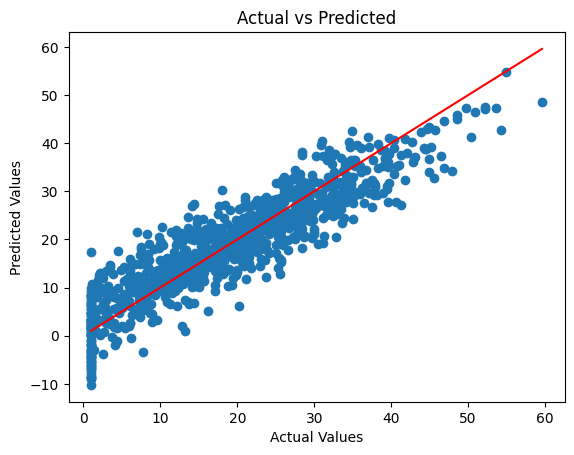

In [ ]:
# Visualization
best_pred = y_pred_elastic

plt.scatter(y_test, best_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
df = pd.read_csv("Student Performance.csv")

In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)


In [ ]:
df = df.drop("student_id", axis=1)

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop("exam_score", axis=1)

In [ ]:
y = df["exam_score"]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [ ]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

pr = LinearRegression()
pr.fit(X_train_poly, y_train)
y_pred_pr = pr.predict(X_test_poly)

In [ ]:
ridge = Ridge()
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

In [ ]:
lasso = Lasso()
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

In [ ]:
elastic = ElasticNet()
elastic.fit(X_train, y_train)
y_pred_elastic = elastic.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
models = {
    "Linear": y_pred_lr,
    "Polynomial": y_pred_pr,
    "Ridge": y_pred_ridge,
    "Lasso": y_pred_lasso,
    "ElasticNet": y_pred_elastic
}

results = []

for name, pred in models.items():
    mse = mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    results.append([name, mse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MSE", "R2"])
print(results_df)

        Model        MSE        R2
0      Linear  24.464479  0.829672
1  Polynomial  25.236972  0.824294
2       Ridge  24.464414  0.829673
3       Lasso  24.423923  0.829955
4  ElasticNet  24.406038  0.830079


In [ ]:
best_model = results_df.loc[results_df["R2"].idxmax()]
print(best_model)

Model    ElasticNet
MSE       24.406038
R2         0.830079
Name: 4, dtype: object


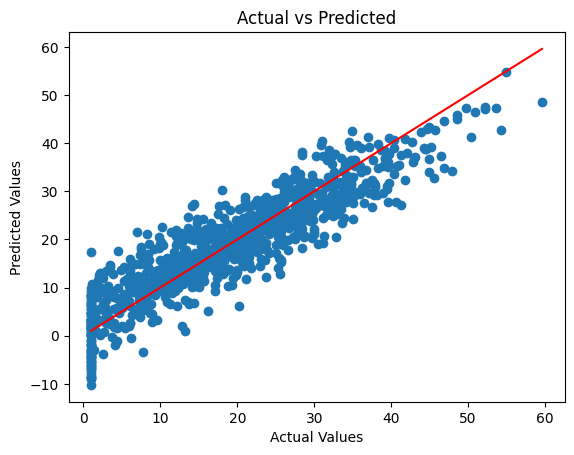

In [ ]:
best_pred = y_pred_elastic

plt.scatter(y_test, best_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("Student Performance.csv")

required_cols = ["Quiz", "Practical", "Project", "Final"]

# Check if required columns exist
if all(col in df.columns for col in required_cols):

    # Create Total column
    df["Total"] = (
        0.1 * df["Quiz"] +
        0.3 * df["Practical"] +
        0.3 * df["Project"] +
        0.3 * df["Final"]
    )

    # Detect outliers
    outlier_dfs = []

    for col in required_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_dfs.append(outliers)

    # Combine and remove duplicates
    all_outliers = pd.concat(outlier_dfs).drop_duplicates()

    # Remove outliers
    df_cleaned = df.drop(index=all_outliers.index).reset_index(drop=True)

    # Save output
    df_cleaned.to_csv("Student_Performance_Cleaned.csv", index=False)

    print("Original dataset shape:", df.shape)
    print("Outliers removed:", all_outliers.shape[0])
    print("Cleaned dataset shape:", df_cleaned.shape)

else:
    print("Error: The dataset does not contain the required columns:")
    print(required_cols)
    print("Available columns are:")
    print(df.columns.tolist())

Error: The dataset does not contain the required columns:
['Quiz', 'Practical', 'Project', 'Final']
Available columns are:
['student_id', 'age', 'gender', 'academic_level', 'study_hours', 'self_study_hours', 'online_classes_hours', 'social_media_hours', 'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes', 'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline', 'internet_quality', 'mental_health_score', 'focus_index', 'burnout_level', 'productivity_score', 'exam_score']


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("Student Performance.csv")

# Create equivalent columns from available data
df["Quiz"] = df["study_hours"]
df["Practical"] = df["self_study_hours"]
df["Project"] = df["productivity_score"]
df["Final"] = df["exam_score"]

# Create target variable
df["Total"] = (
    0.1 * df["Quiz"] +
    0.3 * df["Practical"] +
    0.3 * df["Project"] +
    0.3 * df["Final"]
)

# Detect outliers using IQR
columns = ["Quiz", "Practical", "Project", "Final"]
outlier_dfs = []

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_dfs.append(outliers)

# Combine outliers and remove duplicates
all_outliers = pd.concat(outlier_dfs).drop_duplicates()

# Remove outliers
df_cleaned = df.drop(index=all_outliers.index).reset_index(drop=True)

# Save file
df_cleaned.to_csv("Student_Performance_Cleaned.csv", index=False)

# Output
print("Original dataset shape:", df.shape)
print("Number of outlier rows:", all_outliers.shape[0])
print("Cleaned dataset shape:", df_cleaned.shape)

Original dataset shape: (5000, 26)
Number of outlier rows: 38
Cleaned dataset shape: (4962, 26)
